In [26]:
import pandas as pd
import numpy as np

In [27]:
df = pd.read_csv('Synthetic_Financial_datasets_log.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [28]:
df = df.drop(columns=['nameOrig', 'nameDest'])

In [29]:
df.shape

(6362620, 9)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   oldbalanceDest  float64
 6   newbalanceDest  float64
 7   isFraud         int64  
 8   isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 436.9+ MB


In [31]:
df.describe().astype('int')

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620,6362620,6362620,6362620,6362620,6362620,6362620,6362620
mean,243,179861,833883,855113,1100701,1224996,0,0
std,142,603858,2888242,2924048,3399180,3674128,0,0
min,1,0,0,0,0,0,0,0
25%,156,13389,0,0,0,0,0,0
50%,239,74871,14208,0,132705,214661,0,0
75%,335,208721,107315,144258,943036,1111909,0,0
max,743,92445516,59585040,49585040,356015889,356179278,1,1


In [32]:
df.isnull().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [33]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='isFraud'>

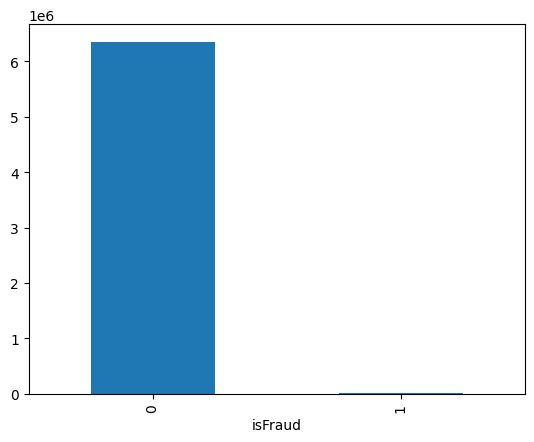

In [35]:
counts = df['isFraud'].value_counts()
counts.plot(kind='bar')

<Axes: >

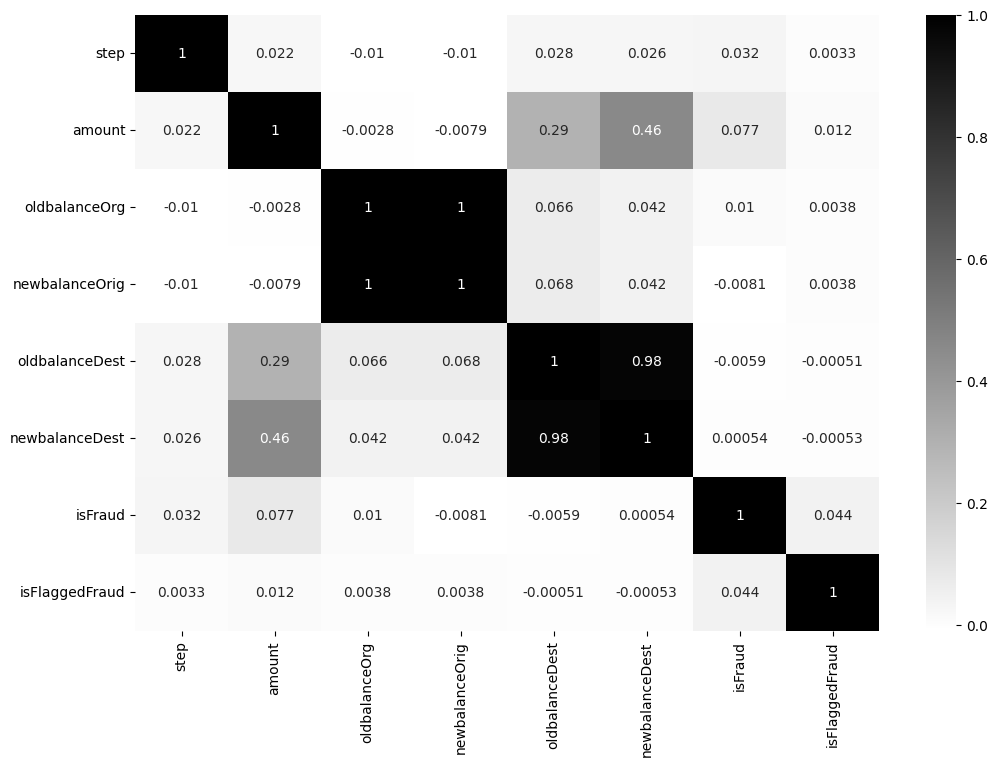

In [36]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='binary')

In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [38]:
x = df.drop(columns=['isFraud'])
y = df.iloc[:,-2]

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x , y, test_size=0.3)

In [40]:
num_cols = ['step','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

ord_col = ['type']
order = [['DEBIT','PAYMENT','CASH_IN','CASH_OUT','TRANSFER']]

In [41]:
num_pipe = Pipeline( steps= [
    ('scaling', StandardScaler())
])

ord_pipe = Pipeline( steps= [
    ('ordinal', OrdinalEncoder(categories=order))
])

In [42]:
y_train.value_counts()

isFraud
0    4448092
1       5742
Name: count, dtype: int64

In [43]:
ratio = int(4448064/5770)
ratio

770

In [44]:
transformation = ColumnTransformer( transformers= [
    ('Numerical', num_pipe, num_cols),
    ('Categorical', ord_pipe, ord_col)
], remainder='passthrough')

In [71]:
model = Pipeline(steps= [
    ('transformation', transformation),
    ('model', XGBClassifier(colsample_bytree= 0.8,
 gamma= 0.1,
 learning_rate= 0.1,
 max_depth= 8,
 scale_pos_weight= 100)),
])

In [72]:
model.fit(x_train, y_train)

,steps,"[('transformation', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical', ...), ('Categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
y_pred = model.predict(x_test)
accuracy_score(y_test, y_pred)

0.9985430530190393

In [74]:
confusion_matrix(y_test, y_pred)

array([[1903582,    2733],
       [     48,    2423]])

In [75]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906315
           1       0.47      0.98      0.64      2471

    accuracy                           1.00   1908786
   macro avg       0.73      0.99      0.82   1908786
weighted avg       1.00      1.00      1.00   1908786



In [50]:
param_grid = param_grid = {
    # 1. Complexity: Deeper trees catch more complex fraud patterns
    'model__max_depth': [4, 6, 8],
    
    # 2. Speed: Lower learning rate makes the model more robust/careful
    'model__learning_rate': [0.01, 0.1],
    
    # 3. Regularization: Prevents the model from over-focusing on noise
    'model__gamma': [0, 0.1, 0.5],
    
    # 4. Sampling: Only looks at a random subset of data for each tree
    'model__colsample_bytree': [0.8, 1.0],
    
    # 5. Balancing: You can try slightly lower ratios to see if Precision improves
    'model__scale_pos_weight': [770, 500] 
}

grid = GridSearchCV(model, param_grid=param_grid, cv=5, scoring='f1')
grid.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.1], 'model__max_depth': [4, 6, ...], ...}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Numerical', ...), ('Categorical', ...)]"


In [58]:
grid.best_score_

np.float64(0.5017082682153226)

In [60]:
grid.best_params_

{'model__colsample_bytree': 0.8,
 'model__gamma': 0.1,
 'model__learning_rate': 0.1,
 'model__max_depth': 8,
 'model__scale_pos_weight': 500}

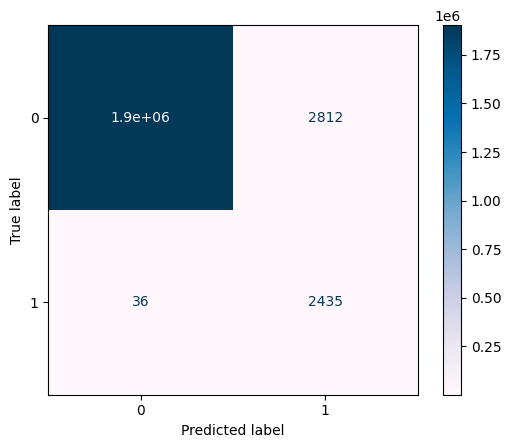

In [51]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap='PuBu')

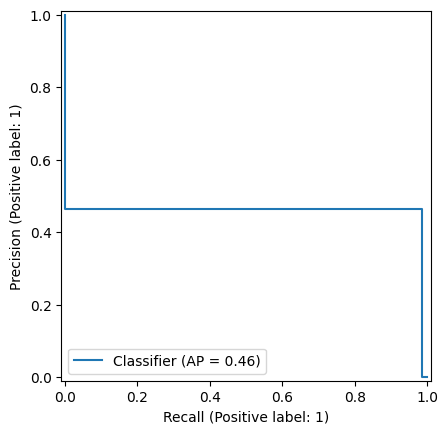

In [52]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred)

In [53]:
import joblib
import gradio as gr

In [54]:
joblib.dump(model, 'Fraud_prediction_model.pkl')

['Fraud_prediction_model.pkl']

In [55]:
m = joblib.load('Fraud_prediction_model.pkl')

def predict(step, t, amount, oldBOrg, newBOrg, oldBD, newBD, isFF):
    frame = pd.DataFrame([[step, t, amount, oldBOrg, newBOrg, oldBD, newBD, isFF]],
                        columns=['step','type','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFlaggedFraud'])

    pred = m.predict(frame)[0]
    if pred == 1:
        return 'Fraud! Alert!'
    else:
        return 'Safe'

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Slider(1,743, label='Step in Hours'),
        gr.Dropdown(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'], label='Step in Hours'),
        gr.Number(label='Enter Amount'),
        gr.Number(label='Enter Old Balance of sender'),
        gr.Number(label='Enter New Balance of sender'),
        gr.Number(label='Enter Old Balance of receiver'),
        gr.Number(label='Enter New Balance of receiver'),
        gr.Radio([0,1], label='Is Flagged fraud ?'),
    ],
    outputs = 'text',
    title='Fraud Detector!'
)
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [56]:
df[df['isFraud'] == 1].head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1,0
3,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1,0
251,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1,0
252,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1,0
680,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1,0


In [57]:
df.sample()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4479990,324,CASH_OUT,609017.26,21630.0,0.0,271900.74,880918.01,0,0
